In [1]:
import equinox as eqx
import grain
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from context_flux_no.data import TheWellDataSource
from context_flux_no.models.multiphysics import (
    AbstractMultiphysicsOperator,
    DISCO,
    DPOT,
)
from context_flux_no.models.multiphysics.hyperfluxfno import (
    HyperFluxFNOLocal,
)
from context_flux_no.training.trainer import Trainer
from jaxtyping import Array, Float, PRNGKeyArray


jax.config.update("jax_default_device", jax.devices("gpu")[1])

In [2]:
source = TheWellDataSource(
    "../../data/datasets",
    "euler_multi_quadrants_periodicBC",
    window_size=11,
    downsample_spatial=8,
    exclude_field_names=["pressure"],
)
sampler = grain.samplers.IndexSampler(len(source), shuffle=True, seed=0)
transforms = [grain.transforms.Batch(batch_size=128)]

In [3]:
dataloader = grain.DataLoader(
    data_source=source,
    sampler=sampler,
    operations=transforms,
    worker_count=8,
    # read_options=grain.ReadOptions(num_threads=32, prefetch_buffer_size=1000),
)
dataloader_valid = grain.DataLoader(
    data_source=TheWellDataSource(
        "../../data/datasets",
        "euler_multi_quadrants_periodicBC",
        "valid",
        window_size=11,
        downsample_spatial=8,
        exclude_field_names=["pressure"],
    ),
    sampler=grain.samplers.IndexSampler(len(source), shuffle=True, seed=1),
    operations=transforms,
    worker_count=8,
    # read_options=grain.ReadOptions(num_threads=32, prefetch_buffer_size=1000),
)

In [9]:
dataiter = iter(dataloader)
batch = next(dataiter)

In [10]:
(batch.dtype.itemsize * batch.size) / 1e9

0.092274688

In [11]:
batch.shape

(128, 11, 4, 64, 64)

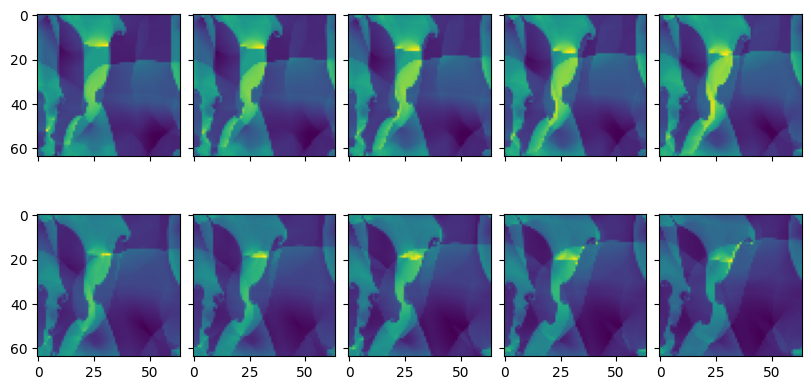

In [12]:
sample_idx = 0
fig, axes = plt.subplots(
    2, 5, figsize=(8, 4), constrained_layout=True, sharex=True, sharey=True
)
for i, ax in enumerate(axes.flat):
    ax.imshow(batch[sample_idx, i, 0])

In [4]:
dpot = DPOT(
    num_spatial_dims=2,
    in_channels=4,
    out_channels=4,
    in_timesteps=10,
    grid_size=(64, 64),
    patch_size=(8, 8),
    embedding_dim=128,
    max_frequency_modes=(10, 10),
    fno_depth=10,
    num_blocks=8,
    hidden_dim_patch=512,
    hidden_dim_fno=512,
    hidden_dim_output=512,
    key=jax.random.key(0),
)
print(dpot.num_parameters() / 1e6)

6.260228


In [25]:
hyperfluxfno = HyperFluxFNOLocal(
    num_spatial_dims=2,
    in_channels=4,
    in_timesteps=10,
    embedding_dim=128,
    encoder_type="TRecViT",
    encoder_kwargs=dict(
        grid_size=(64, 64),
        patch_size=(8, 8),
        depth=2,
        temporal_block_width=128,
        num_heads=8,
        mlp_hidden_dim=64,
    ),
    depth=5,
    lift_dim=128,
    stencil_size=(8, 8),
    width_hyper=128,
    blocks_hyper=4,
    key=jax.random.key(0),
)
print(hyperfluxfno.num_parameters() / 1e6)

6.718728


In [19]:
disco = DISCO(
    num_spatial_dims=2,
    channels=4,
    embedding_dim=128,
    patch_size=8,
    num_hypernet_blocks=3,
    droppath=0.1,
    num_hypernet_heads=8,
    mlp_hidden_dim=32,
    boundary_condition="periodic",
    opnet_hidden_channels=8,
    opnet_norm_groups=4,
    rtol=1e-4,
    atol=1e-6,
    max_steps=16,
    key=jax.random.key(0),
)
print(disco.num_parameters() / 1e6)

6.62227


In [23]:
args = (0.015, 1 / 64, 1 / 64)
compiled = (
    eqx.filter_jit(lambda model, x, args_, key: model(x, args_, key=key))
    .lower(disco, batch[0, :-1], args, jax.random.key(0))
    .compile()
)
flops = compiled.compiled.cost_analysis()["flops"] / 1e9
print(flops)

E0419 20:41:56.104465 2520130 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1.492162432


In [ ]:
eqx.filter_vmap(hyperfluxfno)(batch[:, :-1], args)[0].block_until_ready()

Array([[[[ 7.56072521e-01,  4.48939413e-01,  1.19433594e+00, ...,
           1.53475153e+00,  1.02274084e+00,  8.83468091e-01],
         [ 1.01428688e+00,  1.32706332e+00,  1.10759592e+00, ...,
           1.92772460e+00,  1.40206623e+00,  9.83759761e-01],
         [ 1.46768463e+00,  1.43210757e+00,  1.76071835e+00, ...,
           1.05178893e+00,  1.34343028e+00,  1.27296185e+00],
         ...,
         [ 7.84654200e-01,  9.53222513e-01,  1.65978599e+00, ...,
           2.02145910e+00,  1.57419384e+00,  2.02691436e+00],
         [ 2.68340278e+00,  2.79999971e+00,  1.30215931e+00, ...,
           1.27285361e+00,  1.29516697e+00,  1.39157128e+00],
         [ 7.85369277e-01,  7.54595757e-01,  2.08302617e+00, ...,
           1.52183211e+00,  1.46751308e+00,  2.61611640e-01]],

        [[ 1.07121432e+00,  1.15074837e+00,  2.31704807e+00, ...,
           9.40738797e-01,  1.74581218e+00,  1.29749656e+00],
         [ 2.61525154e+00,  1.78190708e+00,  1.87016380e+00, ...,
           2.00815582e

In [5]:
def loss_fn(
    model: AbstractMultiphysicsOperator,
    u: Float[Array, "batch time dim ..."],
    args,
    key: PRNGKeyArray,
) -> tuple[Float[Array, ""], dict]:
    u0, u1 = u[:, :-1], u[:, -1]
    keys = jax.random.split(key, u0.shape[0])
    u1_pred: Float[Array, "batch dim ..."] = eqx.filter_vmap(
        lambda u_, key_: model(u_, args, key=key_)
    )(u0, keys)[0]
    return jnp.mean((u1 - u1_pred) ** 2), dict()


trainer = Trainer(
    optax.adamw(1e-3),
    loss_fn,
    "./",
    None,
    {"entity": "jhko725", "project": "euler_test"},
    config_dict={"model": ""},
)

In [6]:
trainer.train(dpot, dataloader, dataloader_valid, None, num_steps=500, seed=0)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/jhko725/.netrc.
wandb: Currently logged in as: jhko725 (jhelab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


E0420 13:35:59.992642 3686893 xtile_compiler.cc:399] Fusion: gemm_fusion_dot.110 = f32[2,16384,128]{2,1,0} fusion(bitcast.2, bitcast.12, bitcast.17), kind=kCustom, calls=gemm_fusion_dot.110_computation.clone, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","128"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0420 13:35:59.992836 3686893 xtile_compiler.cc:401] Computation: gemm_fusion_dot.110_computation.clone {
  parameter_1 = f32[1280,8192]{1,0} parameter(1)
  parameter_2 = f32[1280,8192]{1,0} parameter(2)
  concatenate.23 = f32[1280,16384]{1,0} concatenate(parameter_1, parameter_2), dimensions={1}
  bitcast = f32[2,640,16384]{2,1,0} bitcast(concatenate.23)
  parameter_0 = f32[128,2,6

Step: 1 | Train loss: 6.971209526062012 | Valid loss: 
            5.672538757324219
Step: 2 | Train loss: 5.88399600982666 | Valid loss: 
            7.10495138168335


Step: 3 | Train loss: 2.1381402015686035 | Valid loss: 
            3.4795312881469727


Step: 4 | Train loss: 3.045910358428955 | Valid loss: 
            2.257709264755249


...

Step: 32 | Train loss: 0.9868451356887817 | Valid loss: 
            0.49975472688674927


Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(buffer_size=1):
Process grain-process-prefetch-ProcessPrefetchDatasetIterator(bu

ConnectionResetError: Connection lost

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x1475f4176d50>> (for post_run_cell), with arguments args (<ExecutionResult object at 1475981dbec0, execution_count=6 error_before_exec=None error_in_exec=Connection lost info=<ExecutionInfo object at 1475981db620, raw_cell="trainer.train(dpot, dataloader, dataloader_valid, .." transformed_cell="trainer.train(dpot, dataloader, dataloader_valid, .." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bkias-syntax-compute/home/jhko725/projects/CONTEXT_FLUX_NO/notebooks/training/multiphysics_Euler_2d.ipynb#X16sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost